In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('data/cleaned/upi_clean.csv',
                 parse_dates=['timestamp'])
ANALYSIS_DATE = pd.Timestamp('2024-12-31')
os.makedirs('visuals', exist_ok=True)
print("Loaded:", df.shape)

Loaded: (8786, 17)


In [3]:
rfm = df.groupby('user_id').agg(
    recency   = ('timestamp',  lambda x: (ANALYSIS_DATE - x.max()).days),
    frequency = ('transaction_id', 'count'),
    monetary  = ('amount', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)
print(rfm.describe().round(1))
print(f"Total users: {len(rfm):,}")

       recency  frequency  monetary
count    500.0      500.0     500.0
mean      20.1       17.6   23858.1
std       20.5        4.0   11257.9
min        0.0        7.0    4818.4
25%        6.0       15.0   16171.6
50%       14.0       17.0   22253.1
75%       27.0       20.0   29434.8
max      147.0       31.0   88513.6
Total users: 500


In [4]:
rfm['R'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'),
                    5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5])

rfm['RFM_score'] = (rfm['R'].astype(int)
                  + rfm['F'].astype(int)
                  + rfm['M'].astype(int))

def segment(score):
    if score >= 12: return 'Champions'
    if score >= 9:  return 'Loyal'
    if score >= 6:  return 'At Risk'
    return 'Churned'

rfm['segment'] = rfm['RFM_score'].apply(segment)
print(rfm['segment'].value_counts())

segment
Loyal        164
At Risk      154
Champions    115
Churned       67
Name: count, dtype: int64


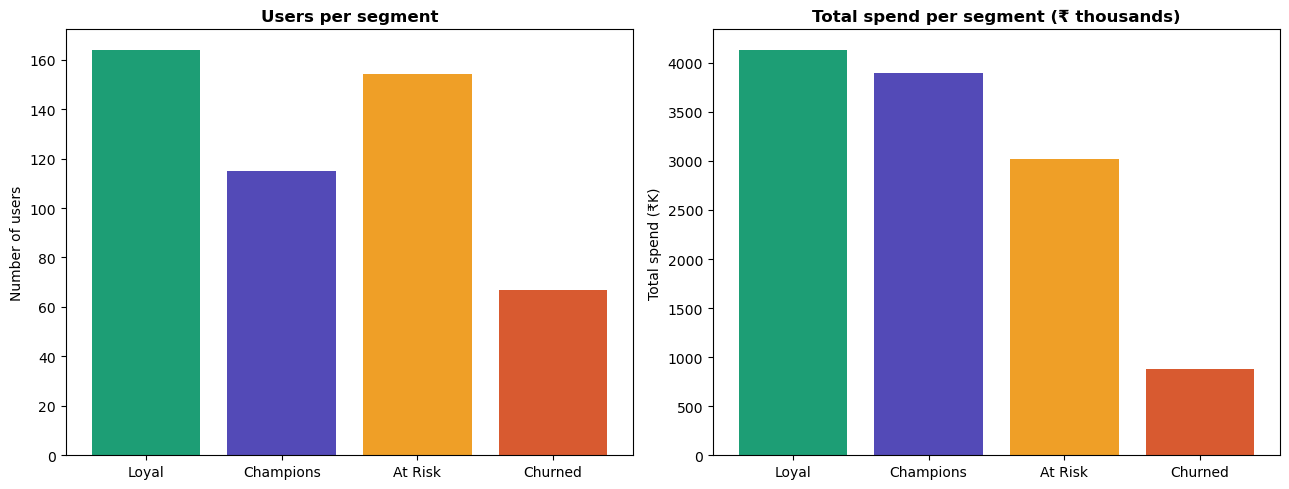

In [5]:
seg_stats = rfm.groupby('segment').agg(
    users=('user_id','count'),
    avg_spend=('monetary','mean'),
    total_spend=('monetary','sum')
).reset_index().sort_values('total_spend', ascending=False)

colors = {'Champions':'#534AB7','Loyal':'#1D9E75',
          'At Risk':'#EF9F27','Churned':'#D85A30'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(seg_stats['segment'], seg_stats['users'],
        color=[colors[s] for s in seg_stats['segment']])
ax1.set_title('Users per segment', fontweight='bold')
ax1.set_ylabel('Number of users')

ax2.bar(seg_stats['segment'], seg_stats['total_spend']/1000,
        color=[colors[s] for s in seg_stats['segment']])
ax2.set_title('Total spend per segment (₹ thousands)', fontweight='bold')
ax2.set_ylabel('Total spend (₹K)')

plt.tight_layout()
plt.savefig('visuals/06_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
rfm.to_csv('data/cleaned/rfm_scores.csv', index=False)

# Key business number for README
at_risk_revenue = rfm[rfm['segment'].isin(['At Risk','Churned'])]['monetary'].sum()
at_risk_users   = rfm[rfm['segment'].isin(['At Risk','Churned'])]['user_id'].count()
print(f"At-risk users:   {at_risk_users}")
print(f"Revenue at risk: ₹{at_risk_revenue:,.0f}")
print("Saved: data/cleaned/rfm_scores.csv")

At-risk users:   221
Revenue at risk: ₹3,895,741
Saved: data/cleaned/rfm_scores.csv
